Matplotlib is building the font cache; this may take a moment.


Дані успішно завантажено.
Перші 10 рядків:


,Unnamed: 0,Link,Text,Label
0,0,https://t.me/c/1376264484/328,"Просто слухайте цей діалог. Ні, це не нарізка ...",True
1,1,https://t.me/c/1376264484/338,️ Рубль став найнестабільнішою валютою у всьом...,True
2,2,https://t.me/c/1376264484/350,Перше звернення мера Мелітополя Івана Федорова...,True
3,3,https://t.me/c/1376264484/361,"Росія загрожує Боснії ""українським сценарієм"" ...",True
4,4,https://t.me/c/1376264484/366,"Енергоатом повідомив, що окупанти пошкодили ви...",True
5,5,https://t.me/c/1376264484/376,Макрон закликає готуватися до великої війни у ...,True
6,6,https://t.me/c/1376264484/386,"Байден має намір заявити Сі Цзіньпіну, що США ...",True
7,7,https://t.me/c/1376264484/391,Урядові літаки РФ здійснили незвичайні рейси з...,True
8,8,https://t.me/c/1376264484/397,У Києві обстріляно житловий квартал у Подільсь...,True
9,9,https://t.me/c/1376264484/400,У США запропонували заблокувати російських кор...,True



Загальна кількість текстів: 10735
Середня довжина (слів): 13.79
Медіанна довжина (слів): 12.0

Розподіл класів:
Label
True     8237
False    2498
Name: count, dtype: int64


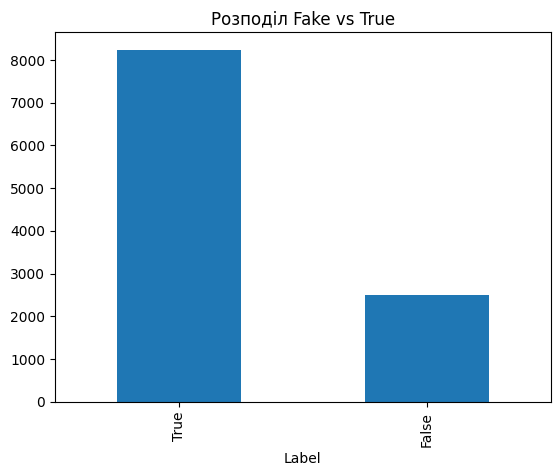


Приклад даних до і після очистки:


,Text,cleaned_text
0,"Просто слухайте цей діалог. Ні, це не нарізка ...","Просто слухайте цей діалог. Ні, це не нарізка ..."
1,️ Рубль став найнестабільнішою валютою у всьом...,️ Рубль став найнестабільнішою валютою у всьом...
2,Перше звернення мера Мелітополя Івана Федорова...,Перше звернення мера Мелітополя Івана Федорова...
3,"Росія загрожує Боснії ""українським сценарієм"" ...","Росія загрожує Боснії ""українським сценарієм"" ..."
4,"Енергоатом повідомив, що окупанти пошкодили ви...","Енергоатом повідомив, що окупанти пошкодили ви..."



Точні дублі: 111 (1.03%)
Дуже короткі тексти (< 5 слів): 22

Оброблений файл збережено як processed.csv


'\nВИСНОВОК:\nДані представляють собою заголовки новин українською мовою. \nОсновний ризик - дисбаланс класів (True значно більше, ніж Fake). \nТакож є певна кількість коротких текстів, які можуть бути неінформативними. \nУ наступних лабораторних потрібно буде звернути увагу на лематизацію та, можливо, \nзастосувати методи аугментації для меншого класу (Fake) або downsampling для більшого.\n'

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. Завантаження даних [cite: 43]
# Припускаємо, що файл лежить у папці ../data/raw.csv відносно ноутбука
try:
    df = pd.read_csv('../data/raw.csv')
    print("Дані успішно завантажено.")
except FileNotFoundError:
    print("Помилка: Файл не знайдено. Перевірте шлях.")

# Виведення перших 10 прикладів [cite: 43]
print("Перші 10 рядків:")
display(df.head(10))

# 2. Статистика [cite: 44]
print(f"\nЗагальна кількість текстів: {len(df)}") # [cite: 45]

# Перевірка назв колонок (у Kaggle датасеті це зазвичай 'Text' і 'Label', але може бути 'title', 'text')
# У коді нижче я використовую 'Text' та 'Label' згідно твого опису.
if 'Text' not in df.columns:
    print("Увага: колонка з текстом не знайдена. Перевірте df.columns")
    # Тимчасово перейменовуємо першу колонку в Text для роботи скрипта
    df.rename(columns={df.columns[0]: 'Text'}, inplace=True)

# Середня та медіанна довжина (слова) [cite: 46]
df['word_count'] = df['Text'].apply(lambda x: len(str(x).split()))
mean_len = df['word_count'].mean()
median_len = df['word_count'].median()
print(f"Середня довжина (слів): {mean_len:.2f}")
print(f"Медіанна довжина (слів): {median_len}")

# Розподіл класів [cite: 47]
if 'Label' in df.columns:
    class_counts = df['Label'].value_counts()
    print("\nРозподіл класів:")
    print(class_counts)
    class_counts.plot(kind='bar', title='Розподіл Fake vs True')
    plt.show()

# 3. Базова нормалізація [cite: 48]
def clean_text(text):
    text = str(text)
    # Прибрати зайві пробіли/переноси [cite: 49]
    text = re.sub(r'\s+', ' ', text).strip()
    # Уніфікувати апостроф [cite: 50]
    text = text.replace("’", "'").replace("`", "'")
    # Замінити URL [cite: 51]
    text = re.sub(r'http\S+', '<URL>', text)
    # Замінити Email (простий regex) [cite: 51]
    text = re.sub(r'\S+@\S+', '<EMAIL>', text)
    return text

df['cleaned_text'] = df['Text'].apply(clean_text)

print("\nПриклад даних до і після очистки:")
display(df[['Text', 'cleaned_text']].head(5))

# 4. Перевірки якості [cite: 52]
# Дублі [cite: 53]
duplicates = df.duplicated(subset=['cleaned_text']).sum()
dup_percentage = (duplicates / len(df)) * 100
print(f"\nТочні дублі: {duplicates} ({dup_percentage:.2f}%)")

# Дуже короткі тексти (< 5 слів) [cite: 54]
short_texts = df[df['cleaned_text'].apply(lambda x: len(x.split()) < 5)]
print(f"Дуже короткі тексти (< 5 слів): {len(short_texts)}")

# 5. Збереження результатів [cite: 34]
# Зберігаємо processed версію (Text -> cleaned_text)
output_df = df[['cleaned_text', 'Label']].rename(columns={'cleaned_text': 'text', 'Label': 'label'})
output_df.to_csv('../data/processed.csv', index=False)
print("\nОброблений файл збережено як processed.csv")

# 6. Висновок (текстовий блок для Markdown комірки в ноутбуці) [cite: 56]
"""
ВИСНОВОК:
Дані представляють собою заголовки новин українською мовою. 
Основний ризик - дисбаланс класів (True значно більше, ніж Fake). 
Також є певна кількість коротких текстів, які можуть бути неінформативними. 
У наступних лабораторних потрібно буде звернути увагу на лематизацію та, можливо, 
застосувати методи аугментації для меншого класу (Fake) або downsampling для більшого.
"""

In [2]:
# 7. Створення labels.csv
# Зберігаємо лише ID та мітку класу
if 'Label' in df.columns:
    df[['Label']].rename(columns={'Label': 'label'}).to_csv('../data/labels.csv', index_label='id')
    print("Файл labels.csv успішно створено у папці data.")
else:
    print("Колонка Label не знайдена.")

Файл labels.csv успішно створено у папці data.
